In [2]:
import pandas as pd

df = pd.read_csv("dataset_2026 (1).csv")

df.head()

,throw_id,team_id,fielder_id,fielder_position,thrower_id,thrower_position,receiver_id,receiver_position,exchange_time,throw_pos_x,...,bounce_velo_y,bounce_velo_z,receiver_pos_x,receiver_pos_y,receiver_dist_from_1b,throw_deflected_by_receiver,start_state,end_state,runs_on_play,batter_result
0,3,11,400,6,400,6,63,3,1.533,-60.116123,...,-25.452504,7.330194,56.199323,60.187776,8.202015,0,____1,1___1,0,first
1,6,11,228,5,390,4,63,3,0.534,-0.562563,...,NaN,NaN,59.013134,65.657938,5.047566,0,1___1,1___2,0,first
2,7,8,415,4,415,4,143,3,1.266,1.598751,...,NaN,NaN,61.037489,64.429134,2.719261,0,123_1,____3,0,out
3,8,8,308,1,308,1,143,3,1.800,25.403185,...,NaN,NaN,63.142075,65.648720,2.069797,0,____1,____2,0,out
4,10,1,314,4,300,6,514,3,0.733,8.957441,...,NaN,NaN,59.770395,64.046058,3.890504,0,123_1,____3,0,out


In [3]:
df.shape

(20000, 30)

In [4]:
df.columns

Index(['throw_id', 'team_id', 'fielder_id', 'fielder_position', 'thrower_id',
       'thrower_position', 'receiver_id', 'receiver_position', 'exchange_time',
       'throw_pos_x', 'throw_pos_y', 'throw_velo_x', 'throw_velo_y',
       'throw_velo_z', 'batter_pos_x_at_throw', 'batter_pos_y_at_throw',
       'batter_velo_at_throw', 'bounce_pos_x', 'bounce_pos_y', 'bounce_velo_x',
       'bounce_velo_y', 'bounce_velo_z', 'receiver_pos_x', 'receiver_pos_y',
       'receiver_dist_from_1b', 'throw_deflected_by_receiver', 'start_state',
       'end_state', 'runs_on_play', 'batter_result'],
      dtype='str')

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Throw distance from release point to receiver position
df["throw_distance"] = np.sqrt(
    (df["receiver_pos_x"] - df["throw_pos_x"])**2 +
    (df["receiver_pos_y"] - df["throw_pos_y"])**2
)

# Throw velocity magnitude
df["throw_velocity"] = np.sqrt(
    df["throw_velo_x"]**2 +
    df["throw_velo_y"]**2 +
    df["throw_velo_z"]**2
)

# Bounced throw
df["throw_bounced"] = df["bounce_pos_x"].notna()

# Runner safe / out made
df["runner_safe"] = df["batter_result"] != "out"
df["out_made"] = df["batter_result"] =="out"

# Errant throw = bounced throw + runner safe
df["errant_throw"] = df["throw_bounced"] & df["runner_safe"]

In [6]:
df[[
    "throw_distance",
    "throw_velocity",
    "throw_bounced",
    "runner_safe",
    "out_made",
    "errant_throw"
]].head()

,throw_distance,throw_velocity,throw_bounced,runner_safe,out_made,errant_throw
0,136.796243,69.340470,True,True,False,True
1,82.565048,69.011990,False,True,False,False
2,83.473573,65.430531,False,False,True,False
3,38.170533,27.407756,False,False,True,False
4,80.254771,82.106379,False,False,True,False


In [7]:
quickest_exchange = (
    df.groupby("team_id")
      .agg(
          avg_exchange_time=("exchange_time", "mean"),
          throws=("throw_id", "count")
      )
      .query("throws >= 20")
      .sort_values("avg_exchange_time")
      .head(5)
)

quickest_exchange

,avg_exchange_time,throws
team_id,,
14,1.119224,1417
6,1.125599,1291
8,1.129689,1240
10,1.129845,1424
13,1.137499,1323


In [8]:
quickest_exchange = (
    df.groupby("fielder_id")
      .agg(
          avg_exchange_time=("exchange_time", "mean"),
          throws=("throw_id", "count")
      )
      .query("throws >= 20")
      .sort_values("avg_exchange_time")
      .head(5)
)

quickest_exchange

,avg_exchange_time,throws
fielder_id,,
783,0.905542,24
13,0.915200,35
394,0.947539,90
750,0.961360,25
407,0.980306,85


In [9]:
team_errant = (
    df.groupby("team_id")
      .agg(
          errant_throws=("errant_throw", "sum"),
          total_throws=("throw_id", "count")
      )
)

team_errant["errant_rate"] = (
    team_errant["errant_throws"] /
    team_errant["total_throws"]
)

team_errant = team_errant.sort_values(
    "errant_rate",
    ascending=False
)

team_errant.head()

,errant_throws,total_throws,errant_rate
team_id,,,
2,85,1362,0.062408
8,75,1240,0.060484
5,79,1383,0.057122
9,75,1326,0.056561
15,74,1323,0.055933


In [10]:
total_errant = (
    df.groupby("team_id")
      .agg(
          errant_throws=("errant_throw", "sum"),
          total_throws=("throw_id", "count"),
      )
)

total_errant["errant_throws"] = (
    total_errant["errant_throws"]
)

total_errant = total_errant.sort_values(
    "errant_throws",
    ascending=False
)

total_errant.head()

,errant_throws,total_throws
team_id,,
2,85,1362
5,79,1383
1,76,1372
7,75,1361
8,75,1240


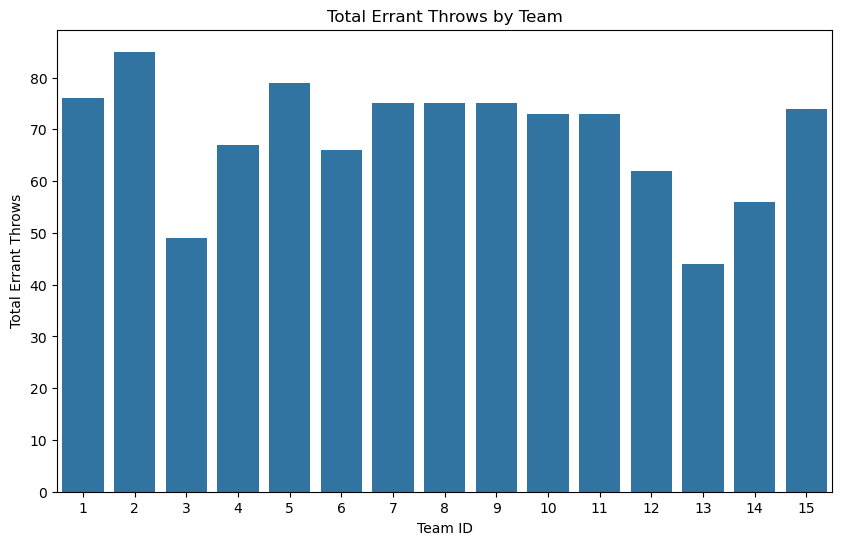

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=team_errant.reset_index(),
    x="team_id",
    y="errant_throws"
)

plt.title("Total Errant Throws by Team")
plt.xlabel("Team ID")
plt.ylabel("Total Errant Throws")

plt.tight_layout
plt.show()

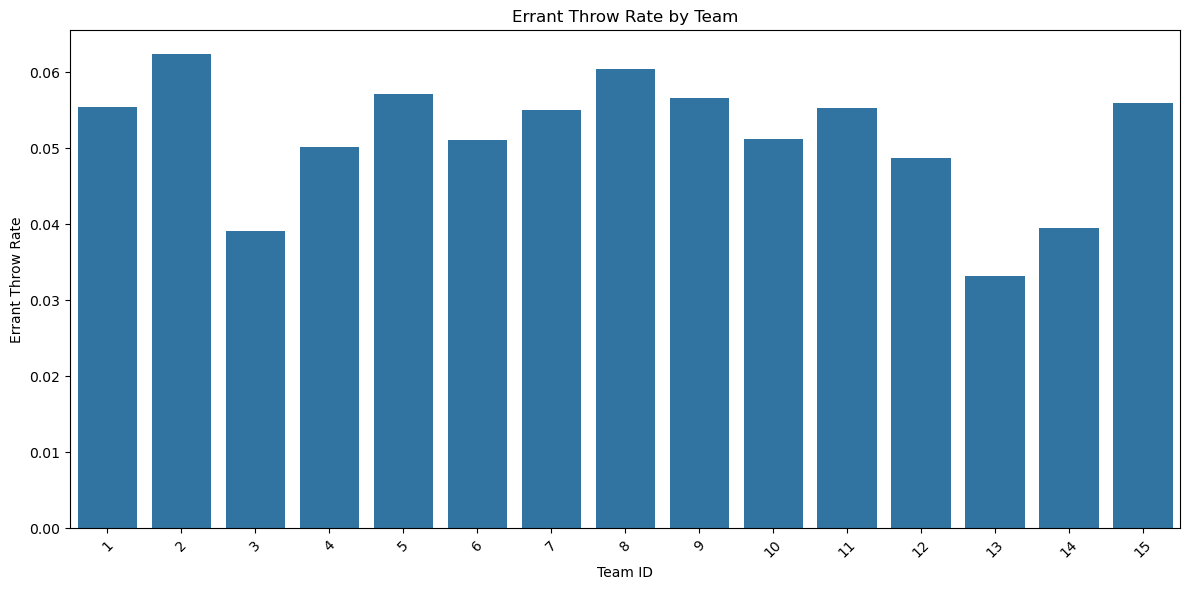

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=team_errant.reset_index(),
    x="team_id",
    y="errant_rate"
)

plt.title("Errant Throw Rate by Team")
plt.xlabel("Team ID")
plt.ylabel("Errant Throw Rate")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
team_errant.head(5)

,errant_throws,total_throws,errant_rate
team_id,,,
2,85,1362,0.062408
8,75,1240,0.060484
5,79,1383,0.057122
9,75,1326,0.056561
15,74,1323,0.055933


In [14]:
distance_cutoff = df["throw_distance"].quantile(0.90)

distance_cutoff

133.66267538720317

In [15]:
long_throws = df[
    df["throw_distance"] >= distance_cutoff
]

long_throws.head()

,throw_id,team_id,fielder_id,fielder_position,thrower_id,thrower_position,receiver_id,receiver_position,exchange_time,throw_pos_x,...,start_state,end_state,runs_on_play,batter_result,throw_distance,throw_velocity,throw_bounced,runner_safe,out_made,errant_throw
0,3,11,400,6,400,6,63,3,1.533,-60.116123,...,____1,1___1,0,first,136.796243,69.340470,True,True,False,True
8,16,1,201,5,201,5,514,3,1.633,-87.229323,...,_23_1,12__1,1,first,140.203258,75.344567,True,True,False,True
37,76,14,607,8,607,8,534,3,1.133,31.997311,...,__3_1,__3_2,0,out,153.474567,91.338274,False,False,True,False
42,82,10,814,6,814,6,50,3,1.200,-52.921261,...,____0,____1,0,out,133.943464,80.430549,False,False,True,False
57,102,6,516,9,516,9,103,3,2.900,199.073474,...,1___1,1___2,0,out,220.410449,86.831752,True,False,True,False


In [16]:
team_long_throws = (
    long_throws.groupby("team_id")
      .agg(
          avg_exchange_time=("exchange_time", "mean"),
          exchange_time_sd=("exchange_time", "std"),
          throw=("throw_id", "count")
      )
      .sort_values("avg_exchange_time")
)

team_long_throws


,avg_exchange_time,exchange_time_sd,throw
team_id,,,
9,1.135676,0.397971,142
2,1.149887,0.406431,151
10,1.153156,0.350946,141
15,1.160896,0.533992,134
6,1.170730,0.384857,122
4,1.171954,0.383797,131
5,1.173658,0.338167,149
11,1.175119,0.451139,160
7,1.179511,0.385538,137


In [17]:
team_long_throws.sort_values(
    "avg_exchange_time"
).head(1)

,avg_exchange_time,exchange_time_sd,throw
team_id,,,
9,1.135676,0.397971,142


In [18]:
team_long_throws.sort_values(
    "exchange_time_sd",
    ascending=False
).head(1)

,avg_exchange_time,exchange_time_sd,throw
team_id,,,
15,1.160896,0.533992,134


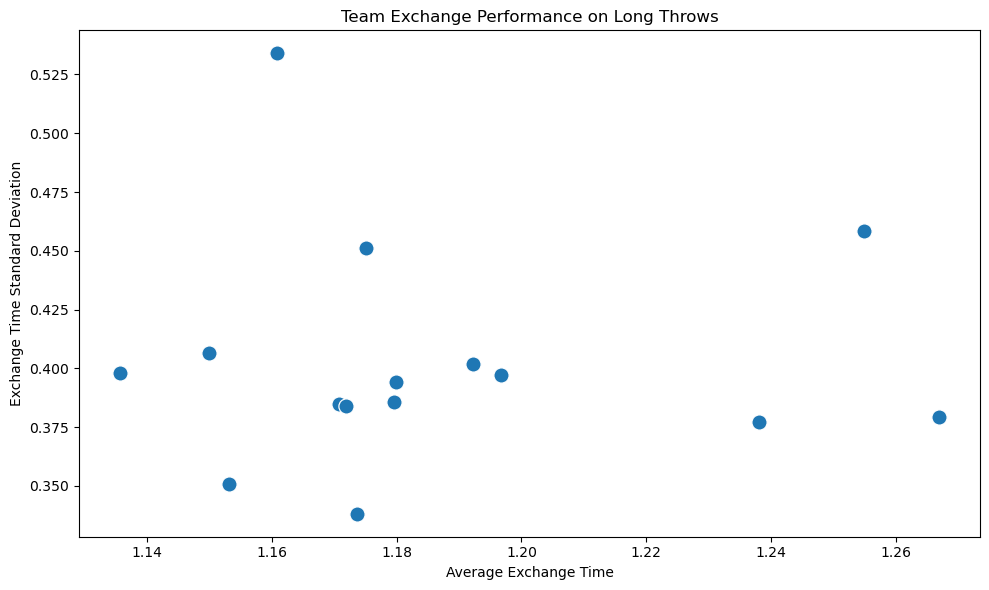

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=team_long_throws.reset_index(),
    x="avg_exchange_time",
    y="exchange_time_sd",
    s=120
)

plt.title("Team Exchange Performance on Long Throws")
plt.xlabel("Average Exchange Time")
plt.ylabel("Exchange Time Standard Deviation")

plt.tight_layout()
plt.show()

In [20]:
short_throws = df[
    df["throw_distance"] <100
]

short_throws.head()

,throw_id,team_id,fielder_id,fielder_position,thrower_id,thrower_position,receiver_id,receiver_position,exchange_time,throw_pos_x,...,start_state,end_state,runs_on_play,batter_result,throw_distance,throw_velocity,throw_bounced,runner_safe,out_made,errant_throw
1,6,11,228,5,390,4,63,3,0.534,-0.562563,...,1___1,1___2,0,first,82.565048,69.011990,False,True,False,False
2,7,8,415,4,415,4,143,3,1.266,1.598751,...,123_1,____3,0,out,83.473573,65.430531,False,False,True,False
3,8,8,308,1,308,1,143,3,1.800,25.403185,...,____1,____2,0,out,38.170533,27.407756,False,False,True,False
4,10,1,314,4,300,6,514,3,0.733,8.957441,...,123_1,____3,0,out,80.254771,82.106379,False,False,True,False
5,11,2,312,4,312,4,695,3,1.200,15.075073,...,____0,____1,0,out,87.044780,74.944144,False,False,True,False


In [21]:
correlation = short_throws["throw_distance"].corr(
    short_throws["throw_velocity"]
)

correlation

0.7331454795195279

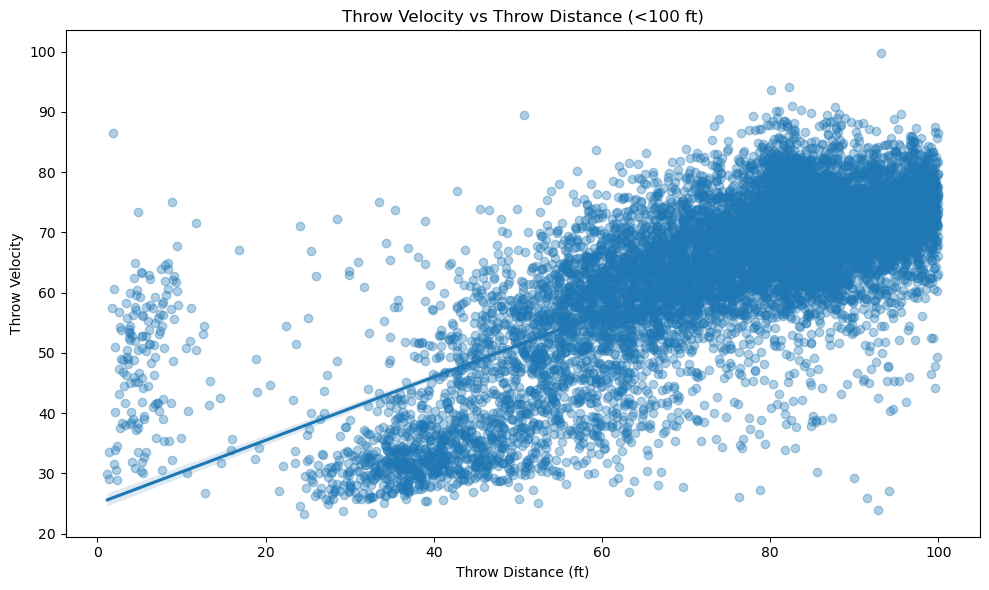

In [22]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=short_throws,
    x="throw_distance",
    y="throw_velocity",
    scatter_kws={"alpha":0.35}
)

plt.title("Throw Velocity vs Throw Distance (<100 ft)")
plt.xlabel("Throw Distance (ft)")
plt.ylabel("Throw Velocity")

plt.tight_layout()
plt.show()

In [56]:
print(f"Correlation: {correlation:.6f}")

Correlation: 0.733145


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("dataset_2026 (1).csv")

# Throw distance
df["throw_distance"] = np.sqrt(
    (df["receiver_pos_x"] - df["throw_pos_x"])**2 +
    (df["receiver_pos_y"] - df["throw_pos_y"])**2
)

# Throw velocity magnitude
df["throw_velocity"] = np.sqrt(
    df["throw_velo_x"]**2 +
    df["throw_velo_y"]**2 +
    df["throw_velo_z"]**2
)

# Throw bounced
df["throw_bounced"] = df["bounce_pos_x"].notna()

# Outcomes
df["runner_safe"] = df["batter_result"] != "out"
df["out_made"] = df["batter_result"] == "out"

# Errant throw
df["errant_throw"] = (
    df["throw_bounced"] &
    df["runner_safe"]
)

In [25]:
player_summary = (
    df.groupby(["fielder_id", "fielder_position"])
      .agg(
          throws=("throw_id", "count"),
          avg_exchange=("exchange_time", "mean"),
          exchange_sd=("exchange_time", "std"),
          avg_velocity=("throw_velocity", "mean"),
          avg_throw_distance=("throw_distance", "mean"),
          out_rate=("out_made", "mean"),
          errant_rate=("errant_throw", "mean"),
          deflection_rate=("throw_deflected_by_receiver", "mean")
      )
      .reset_index()
)

In [26]:
player_summary = player_summary[
    player_summary["throws"] >= 20
]

In [27]:
from scipy.stats import zscore

In [ ]:
player_summary["velocity_z"] = (
    player_summary.groupby("fielder_position")["avg_velocity"]
    .transform(zscore)
)

player_summary["distance_z"] = (
    player_summary.groupby('fielder_position')["avg_throw_distance"]
    .transform(zscore)
)

In [29]:
player_summary["errant_z"] = (
    player_summary.groupby("fielder_position")["errant_rate"]
    .transform(zscore)
)

player_summary["deflection_z"] = (
    player_summary.groupby("fielder_position")["deflection_rate"]
    .transform(zscore)
)

In [30]:
player_summary["consistency_z"] = (
    player_summary.groupby("fielder_position")["exchange_sd"]
    .transform(zscore)
    *-1
)

In [31]:
player_summary["aggression_score"] = (
    0.6 * player_summary["velocity_z"] +
    0.4 * player_summary["distance_z"]
)

In [32]:
player_summary["risk_score"] = (
    0.7 * player_summary["errant_z"] +
    0.3 * player_summary["deflection_z"]
)

In [33]:
player_summary["throw_profile_score"] = (
    0.35 * player_summary["aggression_score"] -
    0.35 * player_summary["risk_score"] +
    0.20 * player_summary["out_rate"] +
    0.10 * player_summary["consistency_z"]
)

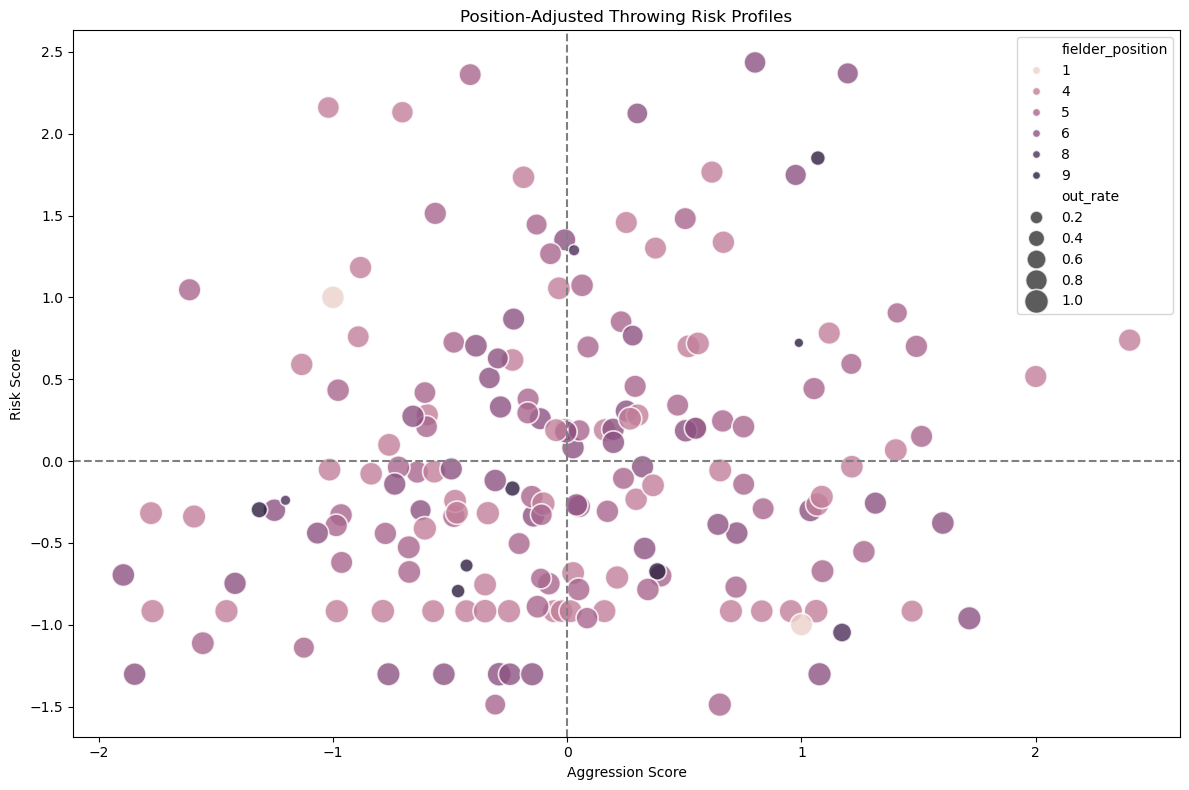

In [34]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=player_summary,
    x="aggression_score",
    y="risk_score",
    hue="fielder_position",
    size="out_rate",
    sizes=(50,300),
    alpha=0.8
)

plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")

plt.title("Position-Adjusted Throwing Risk Profiles")
plt.xlabel("Aggression Score")
plt.ylabel("Risk Score")

plt.tight_layout()
plt.show()




In [36]:
player_summary["exchange_z"] = (
    player_summary.groupby("fielder_position")["avg_exchange"]
    .transform(zscore)
    * -1
)

In [39]:
player_summary["out_rate_z"] = (
    player_summary.groupby("fielder_position")["out_rate"]
    .transform(zscore)
)

In [45]:
player_summary["difficulty_score"] = (
    0.7 * player_summary["distance_z"] +
    0.3 * player_summary["velocity_z"]
)

In [46]:
player_summary["execution_score"] = (
    0.30 * player_summary["velocity_z"] +
    0.30 * player_summary["exchange_z"] -
    0.25 * player_summary["errant_z"] -
    0.15 * player_summary["deflection_z"]
)

In [48]:
player_summary["effectiveness_score"] = (
    (
        0.65 * player_summary["execution_score"] +
        0.35 * player_summary["out_rate_z"]
    )
    *
    (1 + 0.15 * player_summary["difficulty_score"])
)

In [49]:
player_summary.columns

Index(['fielder_id', 'fielder_position', 'throws', 'avg_exchange',
       'exchange_sd', 'avg_velocity', 'avg_throw_distance', 'out_rate',
       'errant_rate', 'deflection_rate', 'velocity_z', 'distance_z',
       'errant_z', 'deflection_z', 'consistency_z', 'aggression_score',
       'risk_score', 'throw_profile_score', 'exchange_z', 'execution_score',
       'out_rate_z', 'difficulty_score', 'effectiveness_score'],
      dtype='str')

In [50]:
player_summary["effectiveness_score"] = (
    (
        0.65 * player_summary["execution_score"] +
        0.35 * player_summary["out_rate_z"]
    )
    *
    (1 + 0.15 * player_summary["difficulty_score"])
)

In [51]:
model_results = (
    player_summary[[
        "fielder_id",
        "fielder_position",
        "throws",
        "difficulty_score",
        "execution_score",
        "out_rate",
        "errant_rate",
        "effectiveness_score"
    ]]
    .sort_values("effectiveness_score", ascending=False)
)

model_results.head(10)

,fielder_id,fielder_position,throws,difficulty_score,execution_score,out_rate,errant_rate,effectiveness_score
469,385,6,35,1.313311,0.991108,0.971429,0.000000,1.460798
687,556,8,22,1.272855,1.099573,0.590909,0.090909,1.438874
446,366,4,22,1.371334,0.639015,1.000000,0.000000,1.237038
483,394,4,24,0.971758,1.141373,0.958333,0.000000,1.139387
901,705,6,53,1.076629,0.712801,0.962264,0.018868,1.139294
944,736,6,27,-0.850631,1.166095,0.962963,0.000000,1.116675
634,516,9,35,0.685554,0.492556,0.485714,0.142857,0.916306
910,711,5,96,1.392335,0.780152,0.906250,0.031250,0.907097
851,673,5,41,0.407468,0.056053,0.975610,0.000000,0.781119
216,188,6,36,-0.041076,0.032397,1.000000,0.000000,0.775114


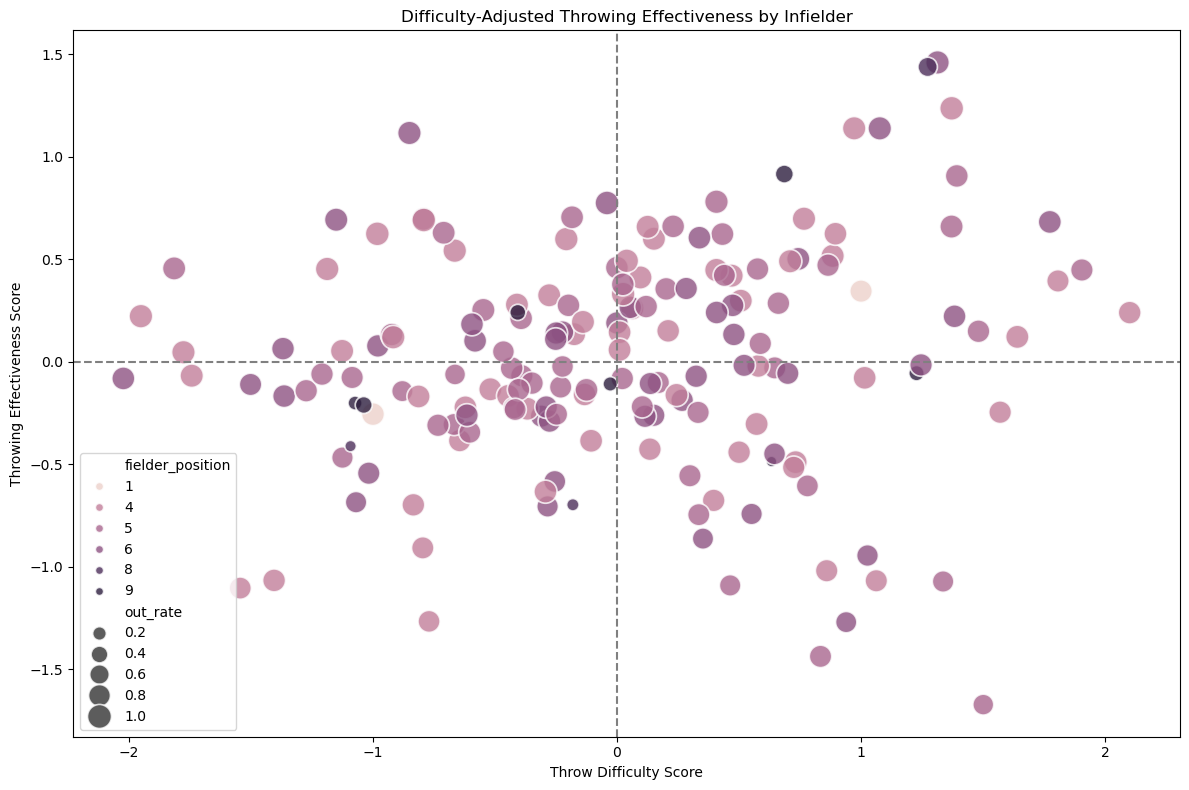

In [52]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=player_summary,
    x="difficulty_score",
    y="effectiveness_score",
    hue="fielder_position",
    size="out_rate",
    sizes=(60,300),
    alpha=0.8
)

plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")

plt.title("Difficulty-Adjusted Throwing Effectiveness by Infielder")
plt.xlabel("Throw Difficulty Score")
plt.ylabel("Throwing Effectiveness Score")

plt.tight_layout()
plt.show()

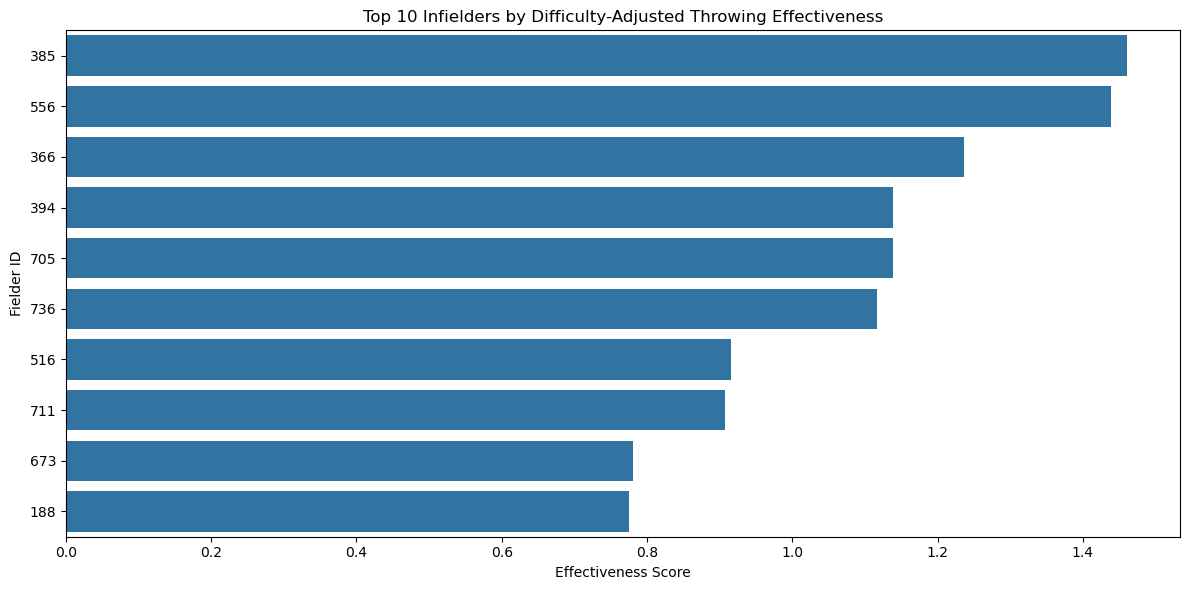

In [53]:
top_10 = model_results.head(10).copy()
top_10["fielder_id"] = top_10["fielder_id"].astype(str)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10,
    x="effectiveness_score",
    y="fielder_id",
    orient="h"
)

plt.title("Top 10 Infielders by Difficulty-Adjusted Throwing Effectiveness")
plt.xlabel("Effectiveness Score")
plt.ylabel("Fielder ID")

plt.tight_layout()
plt.show()